# Baseline Models — Retail Demand Forecasting

Goal:
- Establish naive benchmark forecasts
- Quantify baseline error using simple rules
- Set a performance floor for future models

No machine learning models are used in this notebook.


In [1]:
import pandas as pd
import numpy as np

FEATURE_PATH = "../data/processed/"
df = pd.read_csv(FEATURE_PATH + "features_ca1.csv", parse_dates=["date"])

C:\Users\HP\AppData\Local\Temp\ipykernel_4128\3445862139.py:5: DtypeWarning: Columns (15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FEATURE_PATH + "features_ca1.csv", parse_dates=["date"])


In [2]:
df.shape

(5832737, 24)

In [3]:
df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_type_1,event_name_2,event_type_2,snap_CA,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,is_weekend
0,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,1
1,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,NaN,NaN,NaN,0,3.0,NaN,NaN,NaN,NaN,0
2,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,NaN,NaN,NaN,0,0.0,NaN,NaN,NaN,NaN,0
3,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,...,NaN,NaN,NaN,1,0.0,NaN,NaN,NaN,NaN,0
4,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,...,NaN,NaN,NaN,1,1.0,NaN,NaN,NaN,NaN,0


In [4]:
baseline_df = df.dropna(subset=["lag_1", "rolling_mean_7"]).copy()

In [6]:
baseline_df.shape

(5811394, 24)

In [7]:
split_date = baseline_df["date"].quantile(0.8)

In [8]:
split_date

Timestamp('2015-04-09 00:00:00')

In [9]:
train_df = baseline_df[baseline_df["date"] <= split_date]
test_df  = baseline_df[baseline_df["date"] > split_date]

In [12]:
train_df["date"].min(), train_df["date"].max()

(Timestamp('2011-02-05 00:00:00'), Timestamp('2015-04-09 00:00:00'))

In [13]:
test_df["date"].min(), test_df["date"].max()

(Timestamp('2015-04-10 00:00:00'), Timestamp('2016-04-24 00:00:00'))

In [14]:
test_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_type_1,event_name_2,event_type_2,snap_CA,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,is_weekend
1532,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1533,0,2015-04-10,11510,...,NaN,NaN,NaN,1,0.0,0.0,0.0,0.714286,0.428571,1
1533,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1534,1,2015-04-11,11511,...,Religious,NaN,NaN,0,0.0,2.0,0.0,0.714286,0.428571,1
1534,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1535,2,2015-04-12,11511,...,Religious,NaN,NaN,0,1.0,2.0,0.0,0.571429,0.500000,0
1535,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1536,1,2015-04-13,11511,...,NaN,NaN,NaN,0,2.0,0.0,0.0,0.571429,0.642857,0
1536,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1537,1,2015-04-14,11511,...,NaN,NaN,NaN,0,1.0,0.0,0.0,0.714286,0.714286,0


In [15]:
test_df["pred_naive"] = test_df["lag_1"]

C:\Users\HP\AppData\Local\Temp\ipykernel_4128\3433356466.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["pred_naive"] = test_df["lag_1"]


In [16]:
test_df["pred_roll7"] = test_df["rolling_mean_7"]

C:\Users\HP\AppData\Local\Temp\ipykernel_4128\2243032113.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["pred_roll7"] = test_df["rolling_mean_7"]


In [17]:
test_df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_type_2,snap_CA,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,is_weekend,pred_naive,pred_roll7
1532,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1533,0,2015-04-10,11510,...,NaN,1,0.0,0.0,0.0,0.714286,0.428571,1,0.0,0.714286
1533,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1534,1,2015-04-11,11511,...,NaN,0,0.0,2.0,0.0,0.714286,0.428571,1,0.0,0.714286
1534,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1535,2,2015-04-12,11511,...,NaN,0,1.0,2.0,0.0,0.571429,0.500000,0,1.0,0.571429
1535,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1536,1,2015-04-13,11511,...,NaN,0,2.0,0.0,0.0,0.571429,0.642857,0,2.0,0.571429
1536,FOODS_1_001_CA_1_validation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1537,1,2015-04-14,11511,...,NaN,0,1.0,0.0,0.0,0.714286,0.714286,0,1.0,0.714286


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return mae, rmse

In [28]:
mae_naive, rmse_naive = evaluate(test_df["sales"], test_df["pred_naive"])
mae_roll7, rmse_roll7 = evaluate(test_df["sales"], test_df["pred_roll7"])

In [29]:
mae_naive, rmse_naive

(1.2475972071218222, np.float64(2.761953210753844))

In [30]:
mae_roll7, rmse_roll7

(1.0675095180173642, np.float64(2.240962951561638))

Baseline comparison:
- Naive (lag-1) MAE: 1.2475972071218222
- Naive (lag-1) RMSE: 2.761953210753844
- Rolling-7 MAE: 1.0675095180173642
- Rolling-7 RMSE: 2.240962951561638

Rolling average performs better/worse than naive, indicating
the importance of short-term demand smoothing.

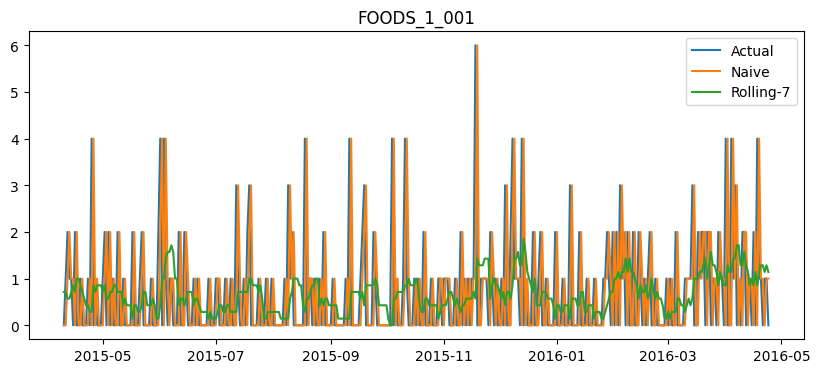

In [31]:
import matplotlib.pyplot as plt

sample_item = test_df["item_id"].iloc[0]
sample = test_df[test_df["item_id"] == sample_item]

plt.figure(figsize=(10,4))
plt.plot(sample["date"], sample["sales"], label="Actual")
plt.plot(sample["date"], sample["pred_naive"], label="Naive")
plt.plot(sample["date"], sample["pred_roll7"], label="Rolling-7")
plt.legend()
plt.title(sample_item)
plt.show()